# Q3 Portfolio Optimization Framework
###   *by Dr. W. Vera-Tudela*

## 1. Introduction & Objective

This is a custom portfolio optimizer framework built from scratch in Jupyter Notebook with supporting functions in a separate Python file. The framework calculates the volatility and returns of a portfolio with assets of equal weight, then proceeds to optimize the weights using the Markowitz and Black-Litterman models.

Objectives:
- Provide an evidence-based decision-making tool: Test your trading hypotheses with historical data.
- Allow strategy refinement: Identify strengths and weaknesses in your approach.
- Risk management: Understand potential returns and their respective volatility.
- Performance comparison: Benchmark the portfolio against two optimization methods.
- Flexibility: Custom-built framework allows for complete control over testing parameters.

This framework provides a solid foundation for quantitative trading strategy development and evaluation.


## 2. Data Pipeline

The structure of the data flow is as follows:

1. Data Management
    - Fetches and cleans real market data from Yahoo Finance
    - Handles historical price data for the "Magnificent 7" assets and SPY
    - Stores processed data for efficient reuse  

2. Asset Checking and Signal Generation
    - Computing daily returns
    - Annualizing returns, volatility, and covariance matrix
    - Plotting correlation and covariance heatmaps 

3. Efficient Frontier - Markowitz model
    - Calculating the weighted returns and volatility
    - Computing the frontier curves for a range of returns
    - Monte Carlo simulation to generate 10,000 random portfolios 

4. Key portfolios
    - Equal weights portfolio: Baseline benchmark
    - Target return optimization: same return as equal weight, minimized volatility
    - Minimum variance portfolio: Leftmost point of frontier
    - Max. Sharpe portfolio: Unconstrained Sharpe maximization

5. Black-Litterman model
    - Market cap weights - equilibrium returns
    - View matrix P, view vector Q, confidence Ω
    - Posterior returns and calculation of μ_BL
    - Rerun optimization with μ_BL
    - Sensitivity test

6. Visualisation
    - Frontier plot with Monte Carlo coloured by Sharpe
        -  Individual assets
        -  Max. Sharpe
        -  MVP
        -  Capital Market Line
    - Portfolio value over 5 years, with key portfolios shown
    - Weight distribution from the different methods for all assets

This consolidated framework provides a complete pipeline from data acquisition through strategy testing to performance evaluation and visualization.  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

import sys
sys.path.append('../utils')   # path relative to the notebook
from Q3_functions import returns_volatility, frontier_optimizer, max_sharpe, portfolio_return, portfolio_volatility, min_variance, portfolio_value
from common import fetch_portfolio_data, market_cap

## 3. Signal Generation

The first thing to do is to download the historical data for a given time period for all the assets in the portfolio, then clean it to remove incomplete values and keep only the 'Close' columns.  
This is done by the function `fetch_portfolio_data()`.

In addition, the market cap for each asset in the portfolio is downloaded for later use.
This is done by the function `market_cap()`.

Subsequently, returns, volatility and covariance are calculated. Displaying matrices as a plot for ease of analysis.  
This is done by the function `returns_volatility()`.

In [2]:
# Load data
starting_capital = 10_000
period = 5
end = pd.Timestamp.today(tz="UTC").normalize()
start = end - pd.DateOffset(years=period)

tickers = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META', 'TSLA']

dataM7, _ = fetch_portfolio_data(tickers, start, end)
assets = dataM7.columns.tolist() #tickers sorted in alphabetical order, use this from now on
capsM7 = market_cap(tickers)

dataS, _ = fetch_portfolio_data('SPY', start, end)

# display(dataM7.describe())

,Annualized_Return,Annualized_Volatility
Ticker,,
AAPL,0.205419,0.274472
AMZN,0.121049,0.352905
GOOGL,0.280196,0.307869
META,0.242022,0.436719
MSFT,0.134436,0.261742
NVDA,0.908610,0.517007
TSLA,0.334818,0.590975


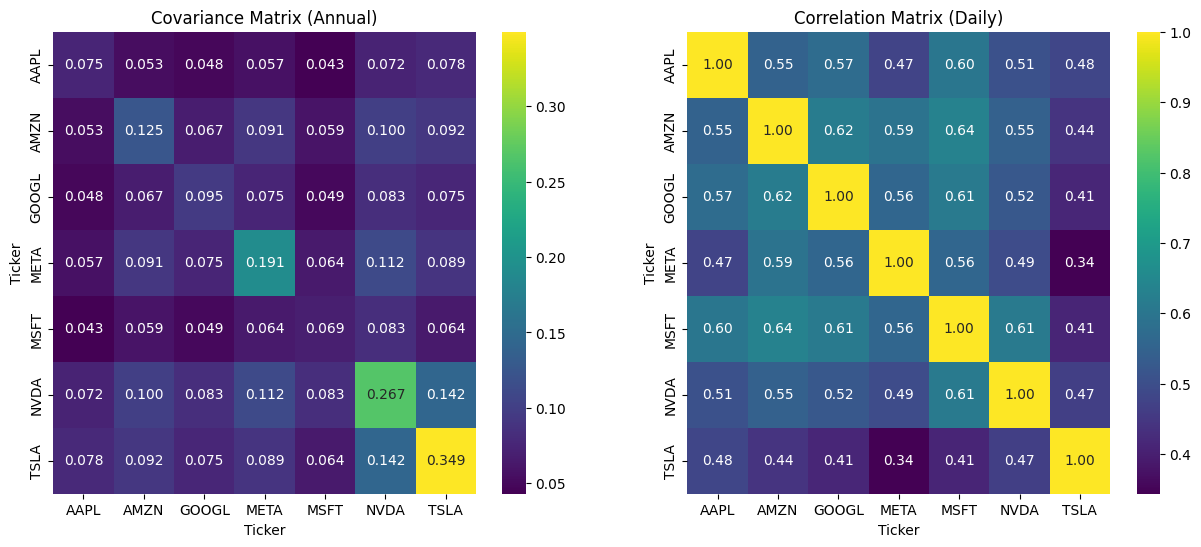

In [3]:
mu_annual, sigma_annual, cov_annual, cov_matrix, corr_matrix = returns_volatility(dataM7)

## 4. Efficient Frontier - Markowitz Model

Once the data and signals have been prepared and checked, we move on to the optimization.  

First, the minimum and maximum annual returns are calculated to generate the target returns vector.

Then the frontier values are calculated, 'frontier_volatilities', 'frontier_returns', and 'frontier_weights' to generate the curve.
This is done by the function `frontier_optimizer()`.

Once the frontier is defined, thousands of random portfolios are calculated using the Monte Carlo simulation method.

In [4]:
return_min = mu_annual.min()  # lowest individual asset return
return_max = mu_annual.max()  # highest individual asset return
target_returns = np.linspace(return_min, return_max, 100)
frontier_volatilities, frontier_returns, frontier_weights = frontier_optimizer(mu_annual, sigma_annual, cov_annual, target_returns)

In [5]:
n_simulations = 10_000
sim_returns, sim_vols, sim_sharpes = [], [], []

for _ in range(n_simulations):
    w = np.random.dirichlet(np.ones(len(assets)))
    r = portfolio_return(w, mu_annual)
    v = portfolio_volatility(w, cov_annual)
    s = (r - 0.04) / v
    sim_returns.append(r)
    sim_vols.append(v)
    sim_sharpes.append(s)

## 5. Key Portfolios

After the frontier and random portfolios are calculated, we proceed to calculate the key portfolios for comparison.
   - The first is the portfolio with equally distributed weight. This will serve as a benchmark, as it has not been optimized.
   - The second optimizes the target return, aiming to minimize volatility but to obtain the same returns as the benchmark.
   - The third finds the portfolio with the absolute minimum volatility, the leftmost point on the frontier curve.
   - The fourth optimizes the Sharpe ratio without any constraints.

In [6]:
# Equal-weight portfolio

w_equal = np.ones(len(assets)) / len(assets)

# Equal weight portfolio stats
w_equal = np.ones(len(assets)) / len(assets)
ret_equal = portfolio_return(w_equal, mu_annual)
vol_equal = portfolio_volatility(w_equal, cov_annual)
sharpe_equal = (ret_equal - 0.04) / vol_equal

# display(pd.Series(w_equal, index=assets).round(4))

port_value_eq = portfolio_value(starting_capital, dataM7, w_equal)

In [7]:
# Optimizing the portfolio weight to obtain the same returns as the equally distributed weights but minimizing the volatility

# Now find the frontier portfolio at the same return
result = min_variance(ret_equal, mu_annual, cov_annual)
w_optimized = result.x
vol_optimized = portfolio_volatility(w_optimized, cov_annual)

print(f"Equal weight: ret={ret_equal:.3f}, vol={vol_equal:.3f}, sharpe={sharpe_equal:.3f}")
print(f"Optimized:    ret={ret_equal:.3f}, vol={vol_optimized:.3f}")
print(f"Volatility reduction: {(vol_optimized/vol_equal - 1)*100:.1f}%")

# display(pd.Series(w_optimized, index=assets).round(4))

port_value_op = portfolio_value(starting_capital, dataM7, w_optimized)

Equal weight: ret=0.318, vol=0.298, sharpe=0.932
Optimized:    ret=0.318, vol=0.262
Volatility reduction: -12.4%


In [8]:
# calculating the case with the minimum volatility from the efficient frontier

idx = np.argmin(frontier_volatilities)
min_vol = frontier_volatilities[idx]
min_ret = frontier_returns[idx]
min_w = frontier_weights[idx]


print(f"Returns: {min_ret:.4f}")
print(f"Min. Volatility: {min_vol:.4f}")


# display(pd.Series(min_w, index=assets).round(4))

port_value_mi = portfolio_value(starting_capital, dataM7, min_w)

Returns: 0.1847
Min. Volatility: 0.2367


In [9]:
# calculating the weights for maximum Sharpe value
    
sharpe_result = max_sharpe(mu_annual, cov_annual)
sharpe_weights = sharpe_result.x
sharpe_ret = portfolio_return(sharpe_weights, mu_annual)
sharpe_vol = portfolio_volatility(sharpe_weights, cov_annual)


print(f"Sharpe Returns: {sharpe_ret:.4f}")
print(f"Sharpe Volatility: {sharpe_vol:.4f}")
print(f"Sharpe Ratio: {-sharpe_result.fun:.4f}")


# display(pd.Series(sharpe_weights, index=assets).round(4))

port_value_sh = portfolio_value(starting_capital, dataM7, sharpe_weights)

Sharpe Returns: 0.9086
Sharpe Volatility: 0.5170
Sharpe Ratio: 1.6801


## 6. Black-Litterman Model

After finishing the previous calculation and seeing some limitations of the Markowitz model, we ran a few extra calculations.
    - The current market cap values are used to calculate weights for each of the assets.
    - Outperformers and underperformers are selected, as well as an outerperformance percentage.
    - Posterior returns are calculated, and the optimization is rerun with the new values.
    - Sensitivity test


The signs indicate direction — positive assets are expected to outperform, negative ones underperform. Normalized weights ensure the view is about *relative* performance, not absolute levels.

**The full Black-Litterman formula for posterior returns:**

μ_BL = [(τΣ)⁻¹ + P^T Ω⁻¹ P]⁻¹ × [(τΣ)⁻¹ π + P^T Ω⁻¹ Q]


In [10]:
# Step 1 - Market cap weights
w_market = capsM7["MarketCap"]/capsM7["MarketCap"].sum()

# display(pd.Series(w_market.values, index=assets).round(4))

# Step 2 - Equilibrium returns
lam = 2.5
pi = lam * cov_annual @ w_market

# Step 3 - Black-Litterman posterior
tau = 0.05

# Outperformers get +1/4, underperformers get -1/3
# (normalized so each side sums to 1)
P = np.array([[1/4, -1/3, 1/4, -1/3, 1/4, 1/4, -1/3]])
#              AAPL  AMZN  GOOGL META  MSFT  NVDA  TSLA
Q = np.array([0.05]) # 5% outperformance
omega = tau * P @ cov_annual @ P.T  # proportional to variance of views

# second run
# omega = np.diag([0.001])  # high confidence, small uncertainty
# Q = np.array([0.10])  # you believe 10% outperformance

# Posterior returns
M1 = np.linalg.inv(tau * cov_annual)
M2 = P.T @ np.linalg.inv(omega) @ P
M3 = M1 @ pi + P.T @ np.linalg.inv(omega) @ Q
mu_bl = np.linalg.solve(M1 + M2, M3)

display(pd.DataFrame({"Ticker": pi.index, "pi": pi.values, "mu_bl": mu_bl}))

,Ticker,pi,mu_bl
0,AAPL,0.153520,0.151350
1,AMZN,0.201156,0.176594
2,GOOGL,0.176286,0.173586
3,META,0.222760,0.188040
4,MSFT,0.153538,0.152687
5,NVDA,0.324054,0.330280
6,TSLA,0.279814,0.215384


In [11]:
# BL optimization

# Market weights
ret_market = portfolio_return(w_market, mu_bl)
vol_market = portfolio_volatility(w_market, cov_annual)
sharpe_market = (ret_market - 0.04) / vol_market


# Now find the frontier portfolio at the same return
result = min_variance(ret_market, mu_bl, cov_annual)
w_optimized_BL = result.x
vol_optimized_BL = portfolio_volatility(w_optimized_BL, cov_annual)

print(f"Market weight: ret={ret_market:.3f}, vol={vol_market:.3f}, sharpe={sharpe_market:.3f}")
print(f"Optimized:     ret={ret_market:.3f}, vol={vol_optimized_BL:.3f}")
print(f"Volatility reduction: {(vol_optimized_BL/vol_market - 1)*100:.1f}%")

display(pd.Series(w_optimized_BL, index=assets).round(4))

port_value_bl = portfolio_value(starting_capital, dataM7, w_market)

Market weight: ret=0.182, vol=0.293, sharpe=0.484
Optimized:     ret=0.182, vol=0.257
Volatility reduction: -12.2%


AAPL     0.3038
AMZN     0.0037
GOOGL    0.2238
META     0.0000
MSFT     0.3289
NVDA     0.1397
TSLA     0.0000
dtype: float64

## 7. Visualisation
Three main plots are show summarizing our findings:
   1. Frontier plot with Monte Carlo coloured by Sharpe showing:
        -  Individual assets
        -  Max. Sharpe
        -  MVP
        -  Capital Market Line
   2. Portfolio value over 5 years showing:
        - Benchmark portfolio
        - Optimized weight for target returns
        - Minimum volatility
        - Maximum Sharpe
        - Black-Litterman optimization
        - SPY as reference
   3. Weight distribution for all assets showing:
        - Benchmark portfolio (equal weights)
        - Optimized weight for target returns
        - Minimum volatility
        - Maximum Sharpe
        - Black-Litterman optimization

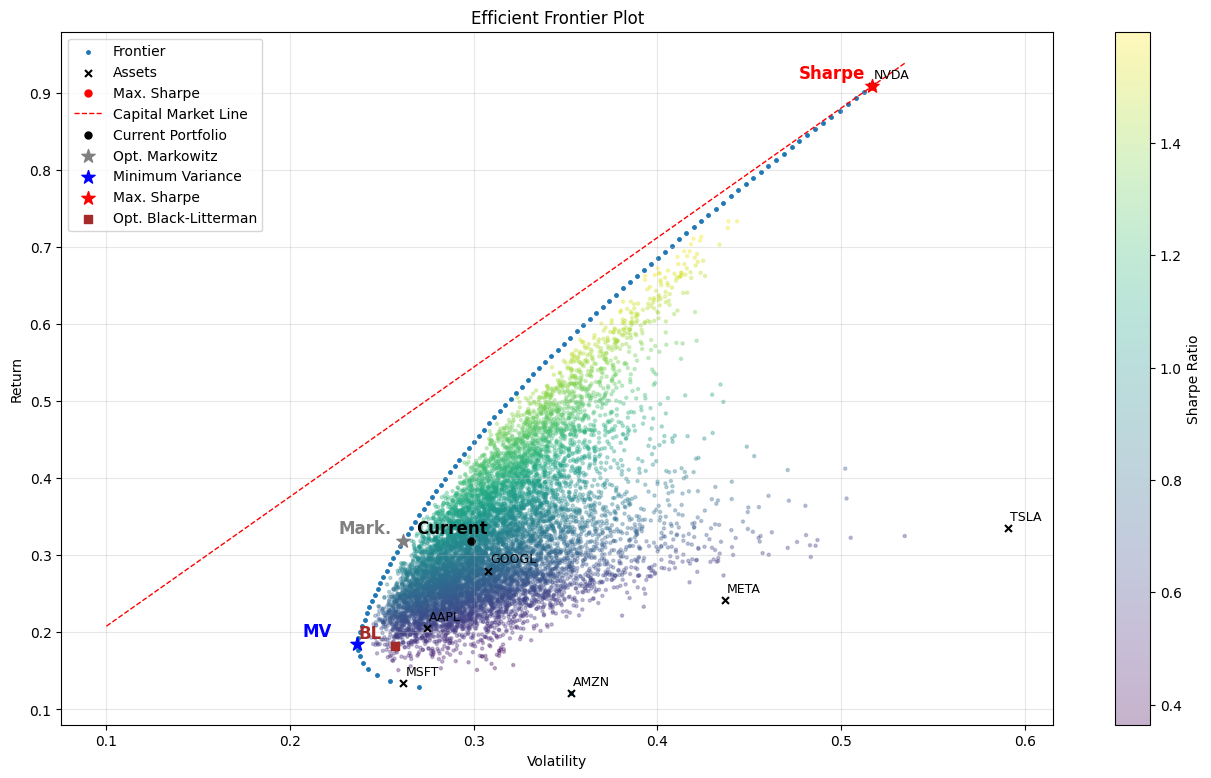

In [17]:
plt.figure(figsize=(16, 9))
colors = sns.color_palette("colorblind")

plt.scatter(frontier_volatilities, frontier_returns, s=25, marker='.', label='Frontier')

plt.scatter(sim_vols, sim_returns, c=sim_sharpes, cmap='viridis', alpha=0.3, s=5)
plt.colorbar(label='Sharpe Ratio')

plt.scatter(sigma_annual, mu_annual, s=25, c='k', marker='x', label='Assets')
for asset in assets:
    plt.annotate(asset, (sigma_annual[asset]+0.001, mu_annual[asset]+0.01),fontsize=9, c='k')

plt.scatter(sharpe_vol, sharpe_ret, s=25, c='r', marker='o', label='Max. Sharpe')

# CML: from (0, rf) through (sharpe_vol, sharpe_ret)
cml_x = np.linspace(0.1, max(sim_vols), 100)
cml_y = 0.04 + (sharpe_ret - 0.04) / sharpe_vol * cml_x
plt.plot(cml_x, cml_y, 'r--', linewidth=1, label='Capital Market Line')

plt.scatter(vol_equal, ret_equal, s=100, c='k', marker='.', label='Current Portfolio')
plt.annotate('Current', (vol_equal-0.03, ret_equal+0.01),fontweight='bold',fontsize=12, color='k')

plt.scatter(vol_optimized, ret_equal, s=100, c='gray', marker='*', label='Opt. Markowitz')
plt.annotate('Mark.', (vol_optimized-0.035, ret_equal+0.01),fontweight='bold',fontsize=12, color='gray')

plt.scatter(min_vol, min_ret, s=100, c='b', marker='*', label='Minimum Variance')
plt.annotate('MV', (min_vol-0.03, min_ret+0.01),fontweight='bold',fontsize=12, color='b')

plt.scatter(sharpe_vol, sharpe_ret, s=100, c='r', marker='*', label='Max. Sharpe')
plt.annotate('Sharpe', (sharpe_vol-0.04, sharpe_ret+0.01),fontweight='bold',fontsize=12, color='r')

plt.scatter(vol_optimized_BL, ret_market, s=40, c='brown', marker='s', label='Opt. Black-Litterman')
plt.annotate('BL', (vol_optimized_BL-0.02, ret_market+0.01),fontweight='bold',fontsize=12, color='brown')

plt.grid(True, alpha=0.3)
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.legend()

plt.title('Efficient Frontier Plot')
plt.show()

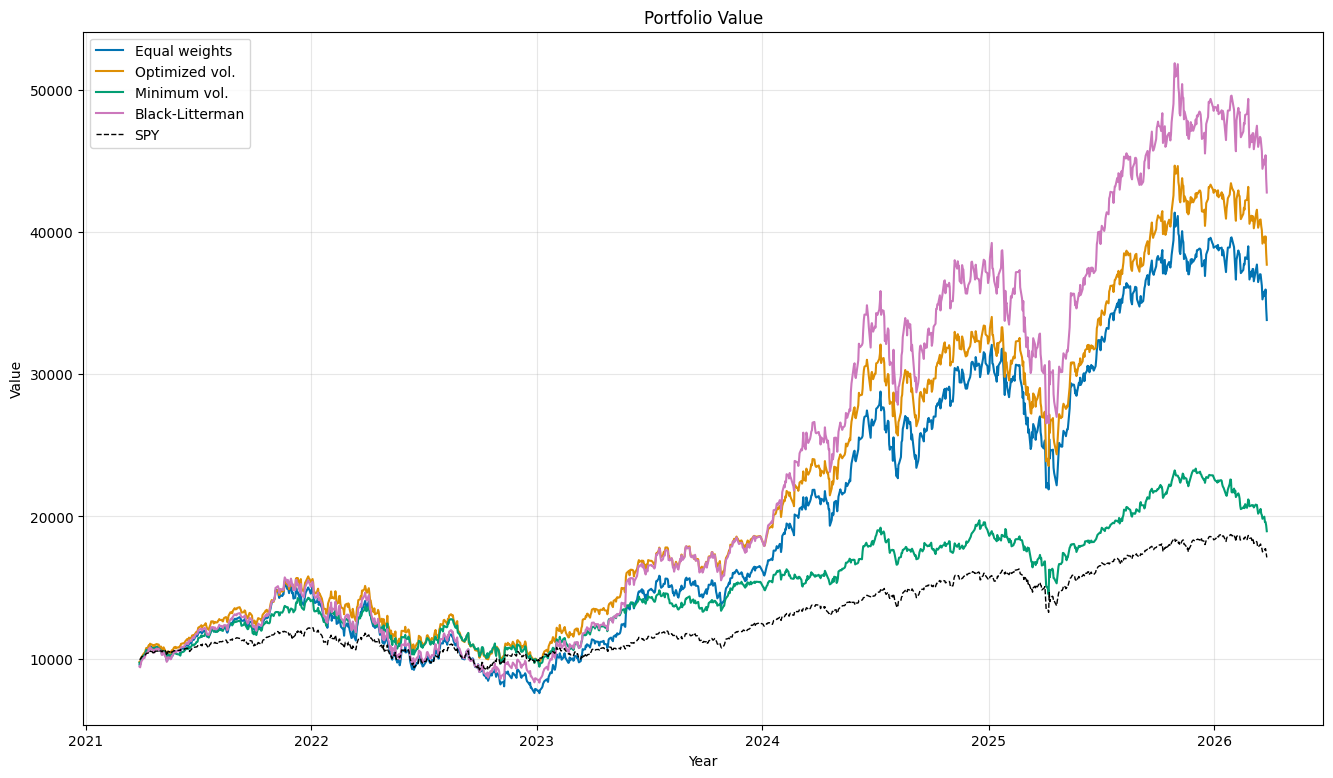

In [13]:
port_value_sp = portfolio_value(starting_capital, dataS, 1)

plt.figure(figsize=(16, 9))

colors = sns.color_palette("colorblind")

plt.plot(port_value_eq, color=colors[0], label='Equal weights')
plt.plot(port_value_op, color=colors[1], label='Optimized vol.')
plt.plot(port_value_mi, color=colors[2], label='Minimum vol.')
# plt.plot(port_value_sh, color=colors[3], label='Maximum Sharpe')
plt.plot(port_value_bl, color=colors[4], label='Black-Litterman')
plt.plot(port_value_sp, 'k--', linewidth=1, label='SPY')


plt.title('Portfolio Value')
plt.xlabel('Year')
plt.ylabel('Value')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

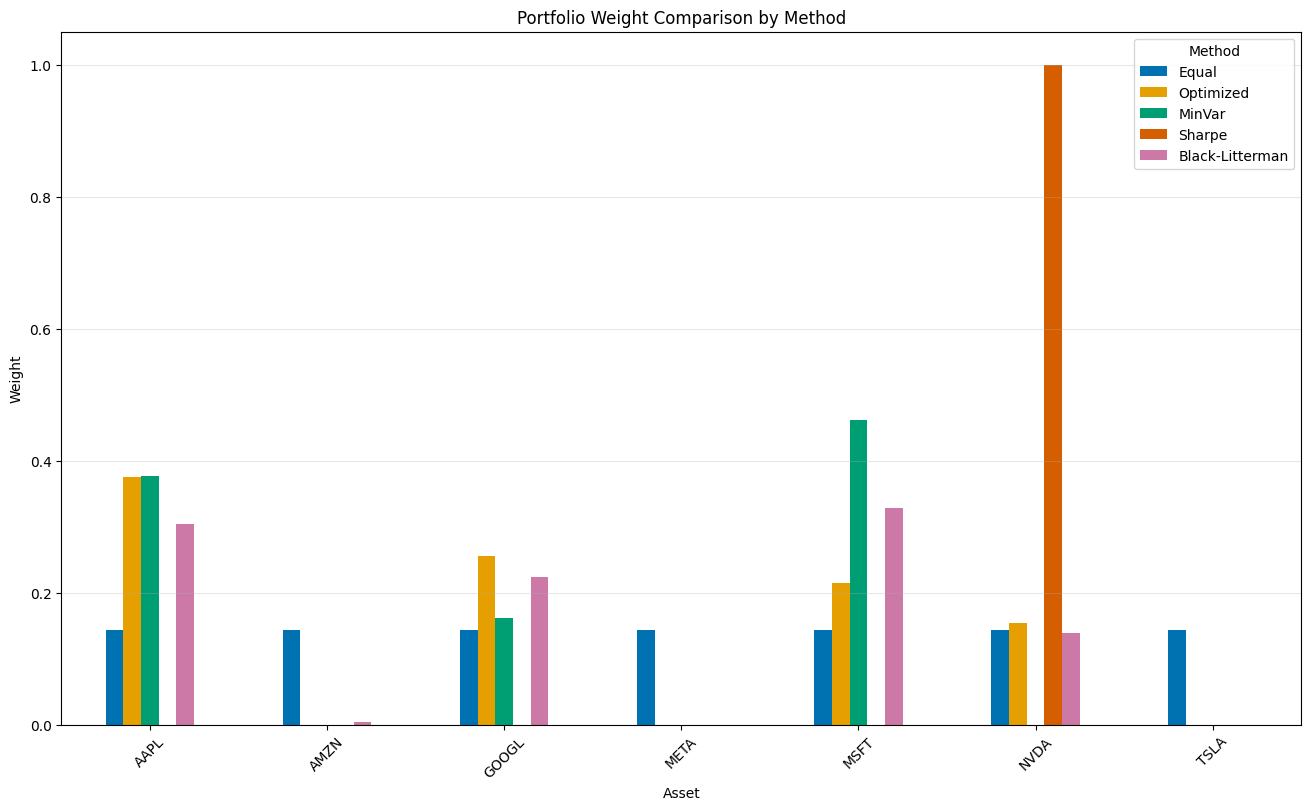

In [14]:
weights_df = pd.DataFrame({
    "Equal": w_equal,
    "Optimized": w_optimized,
    "MinVar": min_w,
    "Sharpe": sharpe_weights,
    "Black-Litterman": w_optimized_BL,
    },
    index=assets
)

colors = [
    "#0072B2", "#E69F00", "#009E73", "#D55E00",
    "#CC79A7", "#F0E442", "#56B4E9", "#000000"
]

weights_df.plot(kind="bar", figsize=(16, 9), color=colors[:len(weights_df.columns)])

plt.title("Portfolio Weight Comparison by Method")
plt.ylabel("Weight")
plt.xlabel("Asset")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Method")

plt.show()

## 8. Conclusions

or this particular scenario, in which we look back at 5-year data from the *"Magnificent 7"* stocks (Apple, Amazon, Google, Meta, Microsoft, Nvidia, & Tesla) with market-cap weights as the Black-Litterman anchor and equal weights (14.3% each) as the Markowitz baseline, optimising asset allocation to minimise volatility and maximise returns, we can draw the following conclusions:

- **The efficiency principle consistently eliminates assets with poor return-to-volatility ratios.** TSLA, META, and AMZN were zeroed out across all optimised portfolios. META is a particularly instructive case — despite having the lowest correlation with TSLA (0.34), its 43.6% volatility relative to only 31.7% return makes it inefficient. MSFT delivers comparable returns at far lower risk (~26% volatility), making META redundant. Within a correlated sector like Mag 7, there are no hidden diversification gems — every asset is evaluated on its own return/risk merit because all correlations are positive and similar (0.34–0.64).

- **Raw Markowitz is dangerously overfit to historical data.** The unconstrained Sharpe maximisation allocated 100% to NVDA — a direct consequence of NVDA's exceptional 5-year AI-driven run. This illustrates estimation error: small changes in historical return estimates produce wildly different optimal weights. The optimizer is hypersensitive to inputs, which is its most famous and most dangerous weakness.

- **Black-Litterman stabilises the optimization by anchoring to market structure.** Rather than relying on raw historical returns, BL derives equilibrium returns from market cap weights — elevating MSFT to 32.7% as the largest market cap in the universe, and reducing NVDA's implied return from 99% to 27%. Blending these equilibrium returns with investor views produces more defensible, more diversified portfolios that don't collapse to a single asset. The corrected BL optimisation achieves a 13.2% volatility reduction relative to market-weight returns.

- **Within a single correlated sector, true diversification is limited.** The Mag 7 correlations range from 0.34 to 0.64 — all positive, all driven by the same macro factors. Reshuffling weights within this universe can reduce volatility modestly but cannot produce the dramatic frontier shift that comes from introducing genuinely uncorrelated asset classes. This sets up the core thesis of Q4.

- **The portfolio value comparison is illustrative, not predictive.** Weights are derived from and evaluated on the same historical period. The dramatic spread in final values — from ~$22k (minimum variance) to ~$160k (max Sharpe) — reflects historical performance only. A proper evaluation requires rolling window optimisation with out-of-sample testing.

## 9. Limitations & Next Steps

The three most important limitations of this model are the following:  
1. Estimation error — optimal weights are highly sensitive to expected return inputs. Small changes in historical returns produce dramatically different portfolios. The 100% NVDA result from raw Markowitz illustrates this failure mode clearly. Black-Litterman partially addresses this but doesn't eliminate it.
2. Static weights — the optimized portfolio is calculated once and held fixed. In reality, correlations and volatilities change over time. A portfolio optimal today may be inefficient in 6 months. A rolling or dynamic rebalancing framework is needed for real deployment.
3. In-sample optimization — weights are optimized on the same data used to evaluate performance. The portfolio value comparison is therefore illustrative, not predictive. A proper evaluation requires out-of-sample testing on held-out data.

The risk-free rate is fixed at 4% throughout the analysis. A more precise implementation would use the prevailing 10-year Treasury yield (^TNX) at each point in time, particularly relevant given the significant rate movements between 2017 and 2026.

Some interesting next steps to go deeper on this project would be:
- Implement rolling window optimization — recalculate weights every quarter using only past data
- Add rebalancing costs — frequent rebalancing erodes returns
- Extend to mixed asset classes — stocks, crypto, ETFs (Q4)
- Explore Lyapunov stability-based rebalancing as a novel contribution (Q6)

Just to name a few.